### Instalación de librerías

In [79]:
from IPython import display
%pip install tensorflow
%pip install keras
%pip install matplotlib
display.clear_output()

### Imports

In [80]:
import json
import keras
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
from keras.models import Sequential
from typing import Tuple, Dict, List
from keras.layers import Embedding, SimpleRNN, Dense

### Desarrollo del desafío

#### Preprocesamiento del corpus

El primer paso consiste en preparar el texto del corpus para que pueda ser utilizado por el modelo de lenguaje. Este bloque se encarga de:

- Cargar el contenido completo del primer libro de Harry Potter.
- Normalizar el texto eliminando inconsistencias (como mayúsculas, espacios dobles o saltos de línea).
- Extraer el vocabulario de caracteres presentes en el corpus.
- Generar los diccionarios necesarios para convertir texto en índices numéricos y viceversa.

Estas transformaciones permiten pasar de un archivo .txt en lenguaje natural a una representación numérica estructurada, lista para ser tokenizada y utilizada en el entrenamiento del modelo.


In [81]:
def load_text_file(file_path: str) -> str:
    """Load the content of a text file.

    :param file_path: Path to the text file
    :return: Content of the file as a single string
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()


def preprocess_text(text: str) -> str:
    """Preprocess the text by converting to lowercase and removing newline characters.

    :param text: Raw text
    :return: Cleaned and normalized text
    """
    text = text.lower().replace('\n', ' ')
    text = text.replace('  ', ' ')
    return text


def create_char_mappings(text: str) -> Tuple[Dict[str, int], Dict[int, str]]:
    """Create character-to-index and index-to-character mappings.

    :param text: Preprocessed text
    :return: Tuple containing char2idx and idx2char dictionaries
    """
    unique_chars = sorted(set(text))
    char2idx = {char: idx for idx, char in enumerate(unique_chars)}
    idx2char = {idx: char for idx, char in enumerate(unique_chars)}
    return char2idx, idx2char


#### Tokenización del texto

Una vez preprocesado el corpus, el siguiente paso consiste en convertir el texto en una secuencia de enteros que representen cada carácter. Esta transformación permite trabajar con el texto de forma numérica, que es el formato que requieren los modelos de redes neuronales.

La tokenización se realiza a nivel de caracteres, utilizando un diccionario que asigna a cada carácter único un índice entero. El resultado es una lista de enteros que representa el texto completo del corpus de forma continua.

Esta secuencia tokenizada será la base para construir los ejemplos de entrenamiento y validación.

In [82]:
def tokenize_text(text: str, char2idx: Dict[str, int]) -> List[int]:
    """Tokenize the text at character level using a provided character-to-index mapping.

    :param text: Preprocessed input text (lowercased, no line breaks)
    :param char2idx: Dictionary mapping characters to integer indices
    :return: List of integer tokens representing the text
    """
    return [char2idx[ch] for ch in text if ch in char2idx]

#### Segmentación del corpus y construcción de datos de entrenamiento y validación

A partir del texto tokenizado, se generan las secuencias de entrenamiento y validación que el modelo utilizará durante el aprendizaje. Este proceso implica recorrer el texto en forma continua con una ventana deslizante de longitud fija (`max_context_size`), lo que permite extraer múltiples subsecuencias superpuestas.

El corpus se divide en dos subconjuntos:
- El conjunto de entrenamiento corresponde a la mayor parte del texto inicial.
- El conjunto de validación se extrae del final del corpus y permite evaluar la capacidad del modelo para generalizar.

Cada una de estas subsecuencias se transforma en un par entrada–objetivo desplazado carácter a carácter:
- La entrada `X` contiene todos los caracteres de la secuencia menos el último.
- El objetivo `y` contiene todos los caracteres excepto el primero, desplazados una posición hacia la izquierda.

Este esquema implementa un enfoque *many-to-many* a nivel temporal, en el cual el modelo produce una predicción por cada carácter de entrada, permitiendo una propagación más rica de gradientes y un entrenamiento más efectivo.


In [83]:
def split_tokenized_text(
    tokenized_text: List[int], 
    max_context_size: int, 
    p_val: float = 0.1
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Split tokenized text into training and validation datasets with aligned input-output sequences.

    :param tokenized_text: List of character-level tokens (as integers)
    :param max_context_size: Total length of each sequence (including input and target)
    :param p_val: Proportion of the text to use for validation
    :return: Tuple containing X_train, y_train, X_val, y_val
    """
    num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))
    train_text = tokenized_text[:-num_val * max_context_size]
    val_text = tokenized_text[-num_val * max_context_size:]

    train_sequences = [
        train_text[i:i + max_context_size]
        for i in range(len(train_text) - max_context_size + 1)
    ]
    val_sequences = [
        val_text[i:i + max_context_size]
        for i in range(len(val_text) - max_context_size + 1)
    ]

    X_train = np.array([seq[:-1] for seq in train_sequences])
    y_train = np.array([seq[1:] for seq in train_sequences])
    X_val = np.array([seq[:-1] for seq in val_sequences])
    y_val = np.array([seq[1:] for seq in val_sequences])

    return X_train, y_train, X_val, y_val


#### Ejecución del pipeline de preprocesamiento y segmentación

En este bloque se integran todas las funciones previamente definidas para preparar los datos que serán utilizados por el modelo. El proceso completo sigue los siguientes pasos:

1. Se carga el contenido del archivo de texto que contiene el corpus.
2. Se aplica el preprocesamiento para normalizar el texto.
3. Se construyen los diccionarios de mapeo entre caracteres e índices.
4. Se tokeniza el texto completo a nivel de caracteres, convirtiéndolo en una secuencia de enteros.
5. Se define el tamaño del contexto (longitud fija de las secuencias de entrada).
6. Se generan las secuencias de entrenamiento y validación a partir del texto tokenizado, dividiéndolo en ventanas adecuadas para alimentar al modelo.

Como resultado, se obtiene un conjunto de datos en formato numérico (X, y) listo para ser utilizado durante el entrenamiento, junto con las secuencias de validación necesarias para evaluar el rendimiento del modelo.


In [84]:
BOOK_DIR = Path("./hp/01 Harry Potter and the Sorcerers Stone.txt")
corpus_text = preprocess_text(load_text_file(BOOK_DIR))
char2idx, idx2char = create_char_mappings(corpus_text)
vocab_size = len(char2idx)
tokenized_text = tokenize_text(corpus_text, char2idx)
max_context_size = 100
X_train, y_train, X_val, y_val = split_tokenized_text(tokenized_text, max_context_size)

In [85]:
print(f'Muestra de texto: {corpus_text[:101]}')
print(f'Número de caracteres únicos: {vocab_size}')
print(f'Longitud del texto tokenizado: {len(tokenized_text)}')
print(f'Longitud de X_train: {X_train.shape}, Longitud de y_train: {y_train.shape}')
print(f'Número de secuencias de validación: {len(X_val)}')

Muestra de texto: mr. and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal
Número de caracteres únicos: 55
Longitud del texto tokenizado: 436199
Longitud de X_train: (392400, 99), Longitud de y_train: (392400, 99)
Número de secuencias de validación: 43601


#### Definición del modelo y métrica de evaluación

Para este modelo de lenguaje se utiliza una capa de Embedding como primer paso en lugar de una codificación one-hot explícita. Esta decisión se basa en que, aunque se trabaja a nivel de caracteres, los vectores densos aprendibles permiten capturar patrones de uso y relaciones estadísticas entre símbolos, mejorando la eficiencia y el rendimiento del modelo. Además, este enfoque reduce el consumo de memoria al evitar representaciones dispersas y escala mejor en caso de ampliar el vocabulario.

El modelo completo incluye:
- Una capa Embedding que transforma cada índice de carácter en un vector denso de dimensión fija.
- Una capa recurrente SimpleRNN que procesa la secuencia temporal de vectores.
- Una capa Dense con activación softmax que predice la probabilidad del próximo carácter en la secuencia.

Para evaluar el rendimiento del modelo durante el entrenamiento, se utiliza un callback personalizado que calcula la perplejidad.

El callback calcula esta métrica exponenciando el valor de la pérdida (loss y val_loss) al final de cada época. Esto proporciona una medida más interpretable que el valor bruto de la función de pérdida, y permite detectar fácilmente sobreajuste o falta de aprendizaje.

In [86]:
class PerplexityCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()

    def on_epoch_end(self, epoch, logs=None):
        # Calculate and log training perplexity
        train_loss = logs.get('loss')
        if train_loss is not None:
            train_perplexity = np.exp(train_loss)
            print(f'\nTraining Perplexity: {train_perplexity:.4f}')
            logs['perplexity'] = train_perplexity

        # Calculate and log validation perplexity if validation data is provided
        val_loss = logs.get('val_loss')
        if val_loss is not None:
            val_perplexity = np.exp(val_loss)
            print(f'Validation Perplexity: {val_perplexity:.4f}')
            logs['val_perplexity'] = val_perplexity

In [87]:
model = Sequential(name='SimpleRNN con capa de embedding')
model.add(Embedding(input_dim=vocab_size, output_dim=32))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model.build(input_shape=(None, max_context_size - 1))
model.summary()

Model: "SimpleRNN con capa de embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 99, 32)         │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 99, 200)        │        46,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 99, 55)         │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,415 (232.09 KB)

 Trainable params: 59,415 (232.09 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
weights_path = Path('hp_simplernn_char.weights.h5')
if weights_path.exists():
    model.load_weights(str(weights_path))
    print('Pesos cargados desde "hp_simplernn_char.weights.h5"')
else:
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=[PerplexityCallback()],
        batch_size=256
    )
    model.save_weights('hp_simplernn_char.weights.h5')
    with open('hp_simplernn_char_training_history.json', 'w') as f:
        json.dump(hist.history, f)

Pesos cargados desde "hp_simplernn_char.weights.h5"


/home/pidg64/Dev/CEIA/PLN/ceia-18co2024-pln/Desafio 3/venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Cargando historial de entrenamiento desde hp_simplernn_char_training_history.json


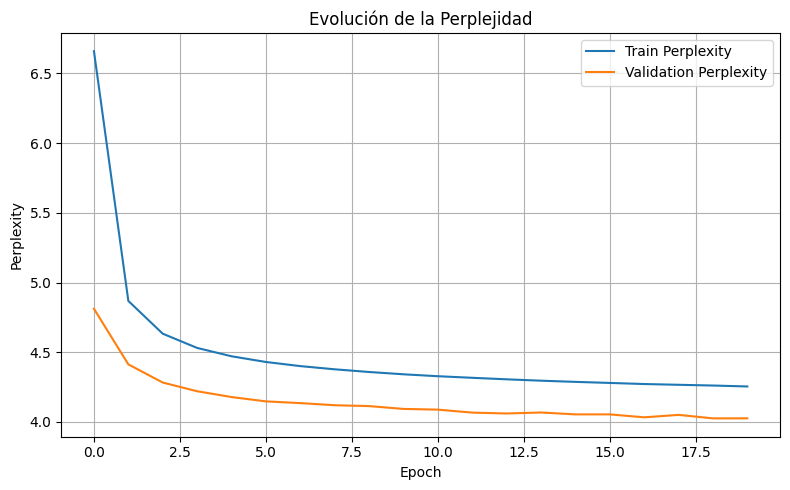

In [89]:
import os

history_path = Path('hp_simplernn_char_training_history.json')
if history_path.exists():
    print(f'Cargando historial de entrenamiento desde {history_path}')
    with open(history_path, "r") as f:
        loaded_history = json.load(f)
    train_perplexity = loaded_history.get('perplexity', [])
    val_perplexity = loaded_history.get('val_perplexity', [])
else:
    print(f'No se encontró el historial de entrenamiento en {history_path}. Usando el historial del modelo.')
    train_perplexity = hist.history.get('perplexity', [])
    val_perplexity = hist.history.get('val_perplexity', [])

plt.figure(figsize=(8, 5))
plt.plot(train_perplexity, label='Train Perplexity')
plt.plot(val_perplexity, label='Validation Perplexity')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Evolución de la Perplejidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()